In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('whitegrid')

In [2]:
# Load the dataset
train_df = pd.read_csv('C:/Users/Itz_Ebuka/Desktop/Machine Learning Projects/Supervised Learning Projects/Classification Projects/Titanic Survival Project/Datasets/titanic_train.csv')

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Exploratory Data Analysis

<Axes: >

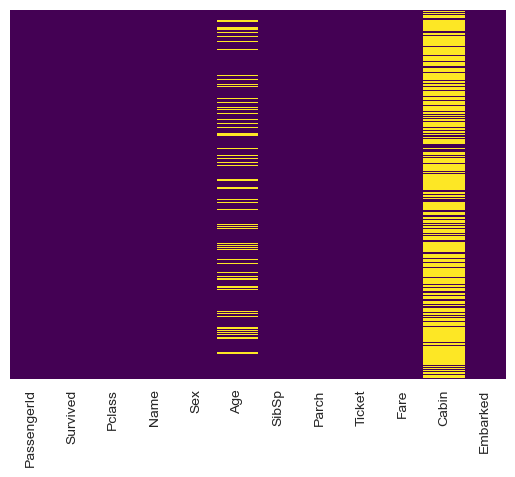

In [4]:
# Visualizing the missing values in the dataset

sns.heatmap(train_df.isna(), yticklabels=False, cbar=False, cmap='viridis')

In [5]:
# Getting the % of missing values
(train_df.isna().sum()/len(train_df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

> About 19.9 % of the data in the Age column is missing, about 77.1 % of the data in the Cabin column is missing and about 0.2 % of the data in the Embarked column is missing

### Understanding the dataset


#### 1. Survival ratio of Passengers

<Axes: xlabel='Survived', ylabel='count'>

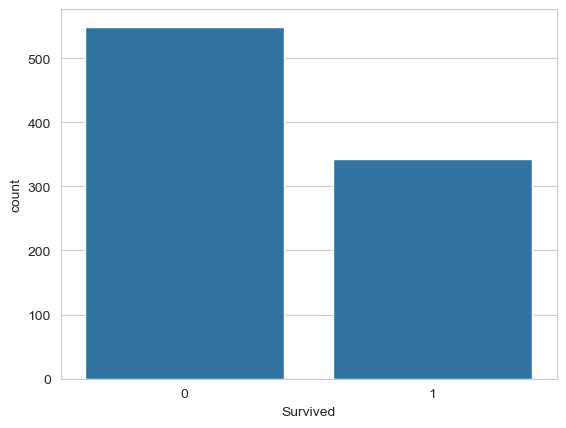

In [6]:
sns.countplot(x='Survived', data=train_df)

#### 2. Survival ratio by gender

<Axes: xlabel='Survived', ylabel='count'>

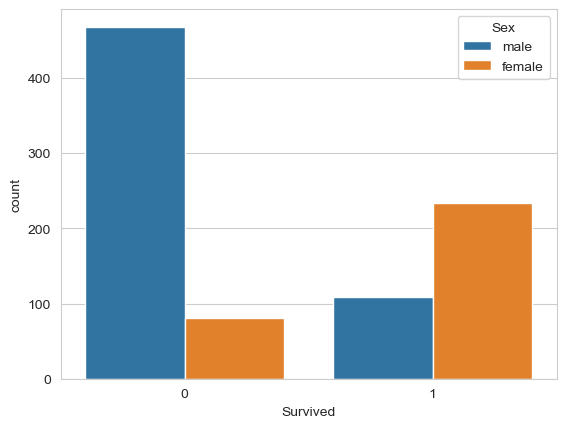

In [7]:
sns.countplot(x='Survived', data=train_df, hue='Sex')

#### 3. Survival rate by Passenger class

<Axes: xlabel='Survived', ylabel='count'>

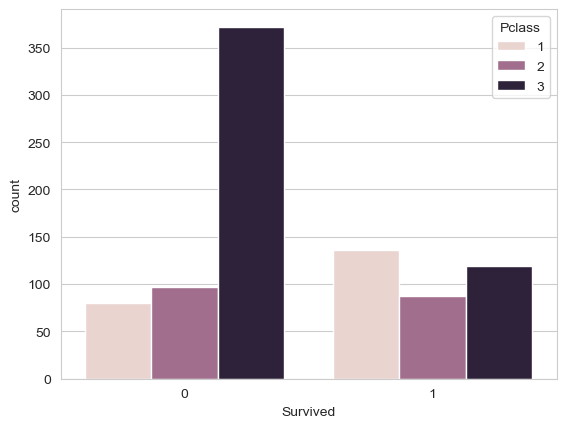

In [8]:
sns.countplot(x='Survived', data=train_df, hue='Pclass')

#### 4. Age distribution of passengers on the titanic

C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_6680\617356869.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df['Age'].dropna(), kde = False, bins = 40)


<Axes: xlabel='Age'>

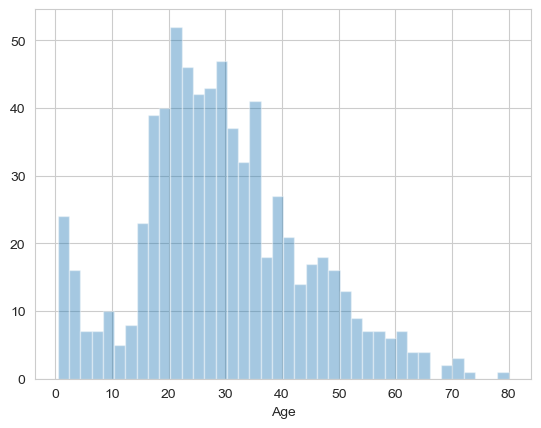

In [9]:
sns.distplot(train_df['Age'].dropna(), kde = False, bins = 40)

#### 5. Siblings/Spouse on the titanic

<Axes: xlabel='SibSp', ylabel='count'>

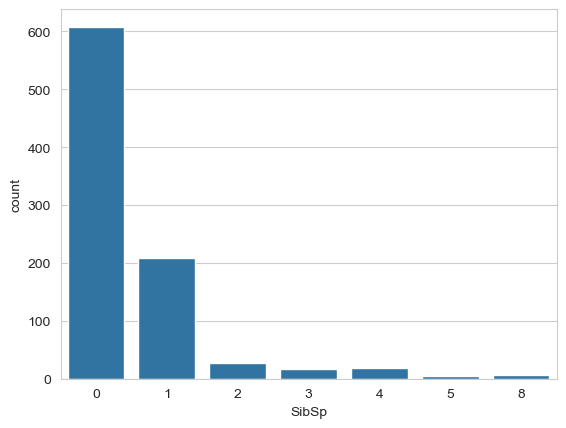

In [10]:
sns.countplot(x='SibSp', data=train_df)

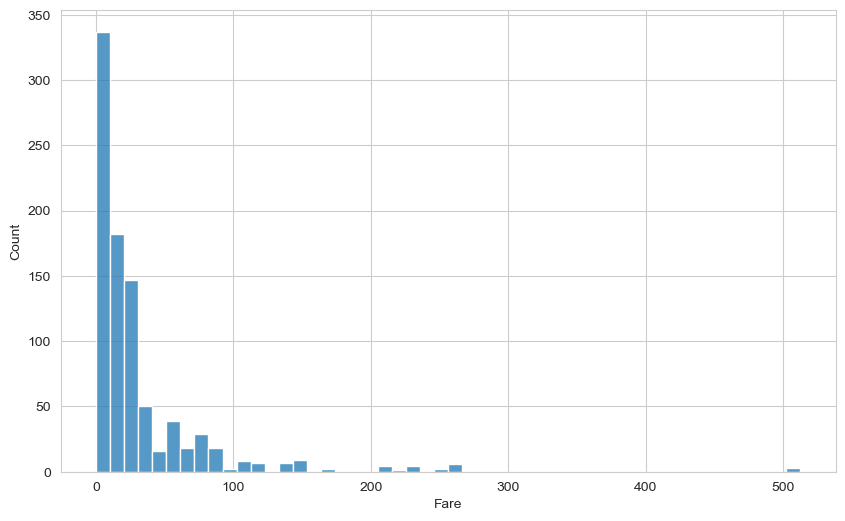

In [11]:
plt.figure( figsize = (10, 6))
sns.histplot(train_df['Fare'], bins = 50)

plt.show()

In [12]:
import cufflinks as cf

cf.go_offline()

In [13]:
train_df['Fare'].iplot(kind='hist', bins = 40)

### Data Cleaning/ Preprocessing

#### i. Filling the Missing age values

In [14]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

In [15]:
train_df['Age'] = train_df[['Age', 'Pclass']].apply(impute_age, axis = 1)

C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_6680\1334420608.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_6680\1334420608.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<Axes: >

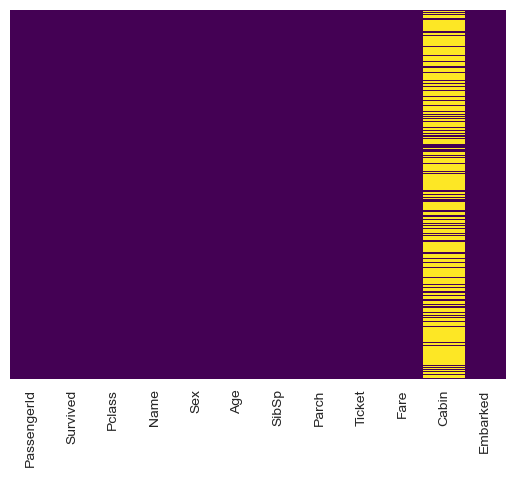

In [16]:
# Checking to see if the Age column has any missing value

sns.heatmap(train_df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

The Age Column is now clean.......no missing values

#### ii. Dropping the cabin column

In [17]:
train_df.drop('Cabin', axis = 1, inplace = True)

In [18]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


#### iii. Dropping missng values in the Embarked column

In [19]:
train_df.dropna(inplace = True)

<Axes: >

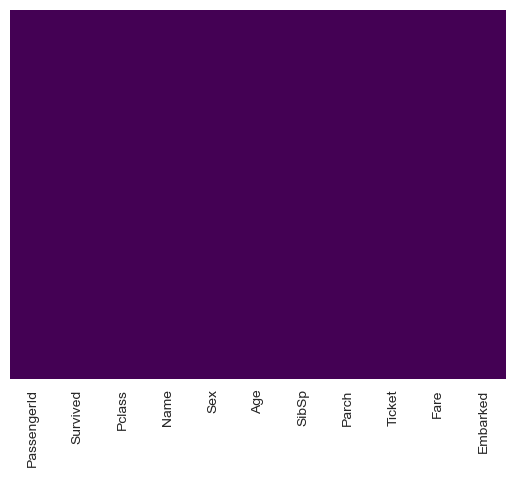

In [20]:
sns.heatmap(train_df.isna(), yticklabels = False, cbar = False, cmap = 'viridis')

No missing values............hurray!!!

#### iv. Handle the categorical columns

In [21]:
train_df = pd.get_dummies(train_df, columns = ['Sex', 'Embarked'], drop_first = True)

In [22]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


#### Dropping columns that we cannot work with 

In [23]:
## Dropping the PassengerId, Name and Ticket columns
train_df.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace = True)

In [24]:
train_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


The data set is now clean......now we can build our classification model

### Building the classification model

#### 1. Logistic Regression

In [25]:
# Selecting the features and target variables
X = train_df.drop('Survived', axis = 1)
y = train_df['Survived']

In [26]:
# Splitting the dataset into test and train sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

In [27]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [28]:
# Create an Instance of the model
log_model = LogisticRegression()

In [29]:
# Fit the model
log_model.fit(X_train, y_train)

C:\Users\Itz_Ebuka\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [30]:
# Make predictions
predictions = log_model.predict(X_test)

In [31]:
# Evaluating the model performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Report: ', classification_report(y_test, predictions))

Report:                precision    recall  f1-score   support

           0       0.83      0.84      0.83       114
           1       0.71      0.69      0.70        64

    accuracy                           0.79       178
   macro avg       0.77      0.76      0.77       178
weighted avg       0.79      0.79      0.79       178



In [32]:
print(confusion_matrix(y_test, predictions))

[[96 18]
 [20 44]]


In [33]:
print(accuracy_score(y_test, predictions))

0.7865168539325843


# Phase 2: Using a Pipeline for Data Cleaning Process and Model building with the train data and test data

In [18]:
# Load the train and test data
train_data = pd.read_csv('C:/Users/Itz_Ebuka/Desktop/Machine Learning Projects/Supervised Learning Projects/Classification Projects/Titanic Survival Project/Datasets/titanic_train.csv')
test_data = pd.read_csv('C:/Users/Itz_Ebuka/Desktop/Machine Learning Projects/Supervised Learning Projects/Classification Projects/Titanic Survival Project/Datasets/titanic_test.csv')

In [19]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [21]:
train_data.shape

(891, 12)

In [22]:
test_data.shape

(418, 11)

In [23]:
# Checking for missing values

(train_data.isna().sum()/len(train_data))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [24]:
(test_data.isna().sum()/len(test_data))*100

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

<Axes: >

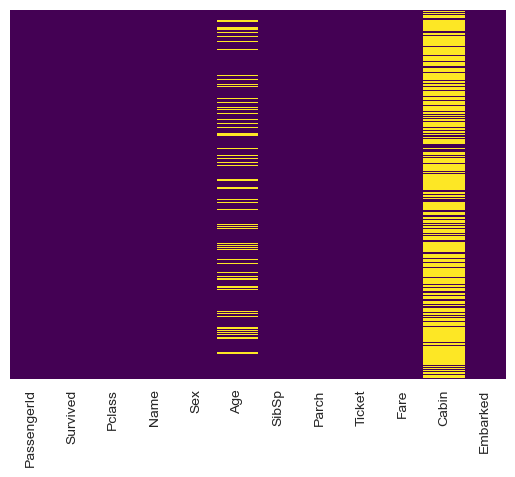

In [25]:
# Plotting the missing values
sns.heatmap(train_data.isna(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: >

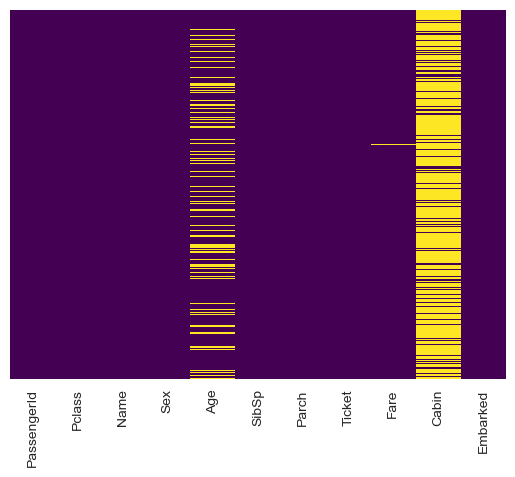

In [26]:
sns.heatmap(test_data.isna(), yticklabels=False, cbar=False, cmap='viridis')

In [27]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


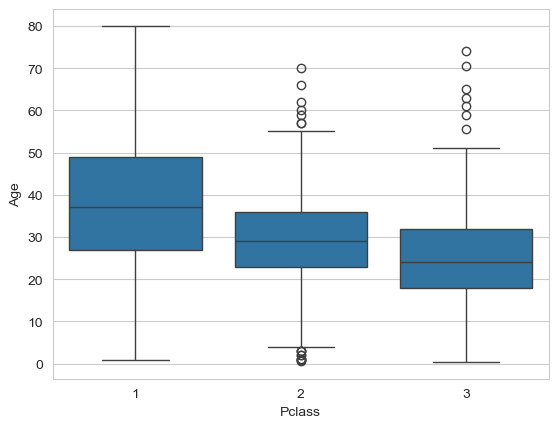

In [29]:
sns.boxplot(data = train_data, x= 'Pclass', y='Age')
plt.show()

<Axes: xlabel='Pclass', ylabel='Fare'>

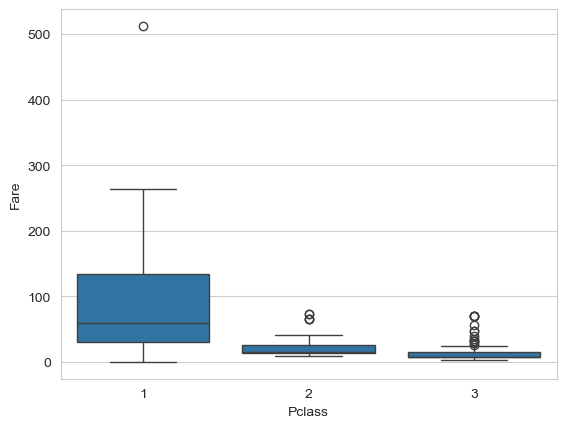

In [30]:
sns.boxplot(data = test_data, x = 'Pclass', y='Fare')

## Data Cleaning and Preprocessing

In [31]:
# Selecting the target and features variable
X = train_data.drop(['PassengerId', 'Cabin', 'Name', 'Ticket', 'Survived'], axis = 1)
y = train_data['Survived'].copy()

X_test_final =  test_data.drop(['PassengerId', 'Cabin', 'Name', 'Ticket'], axis = 1)

In [32]:
X.shape

(891, 7)

In [34]:
X_test_final.shape

(418, 7)

In [35]:
# Selecting the column types
num_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Sex', 'Embarked']

In [37]:
# Using Pipeline to handle the cleaning process
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Creating the numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')), # Handles all missing values 
    ('scaler', StandardScaler()) # Scales numerical values
])

# 2. Creating the categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')), # Handles missing values 
    ('onehot', OneHotEncoder(handle_unknown = 'ignore')) # Converts to dummy values
])

# 3. Combine both pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])






In [38]:
# Full Pipeline with the Logistic Regression model
from sklearn.linear_model import LogisticRegression
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [43]:
# Splitting the training data 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)

# Fit the model
model_pipeline.fit(X_train, y_train)

# Score the trained model
score = model_pipeline.score(X_test, y_test)
print('Trained Model Accuracy: ', score)




Trained Model Accuracy:  0.8044692737430168


In [44]:
# Make predictions with the test data
predictions = model_pipeline.predict(X_test_final)


In [46]:
# Model predictions on the target column
output = pd.DataFrame({
    'PassengerId' : test_data['PassengerId'],
    'Survived' : predictions
})

In [47]:
output.head(20)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
